# Exploratory Data Analysis

## Imports


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.spatial.distance import mahalanobis

## Data exploration

In [26]:
df = pd.read_csv("tobacco-nir-all.csv")

df.head()

,Sample ID,Planting year,Country,10001.0283203125,9997.17138687565,9993.31445343881,9989.45752000196,9985.60058656511,9981.74365312826,9977.88671969142,...,4034.35229350975,4030.4953600729,4026.63842663606,4022.78149319921,4018.92455976236,4015.06762632551,4011.21069288867,4007.35375945182,4003.49682601497,3999.63989257813
0,1,2021,Argentina,0.292623,0.292518,0.292467,0.292411,0.292361,0.292286,0.292234,...,0.677369,0.679197,0.680607,0.681998,0.682849,0.683569,0.683807,0.683901,0.683700,0.683342
1,2,2020,Argentina,0.286529,0.286403,0.286367,0.286338,0.286218,0.286121,0.286069,...,0.694849,0.696874,0.698492,0.699980,0.700895,0.701691,0.701907,0.702025,0.701868,0.701515
2,3,2021,Argentina,0.286912,0.286834,0.286778,0.286690,0.286588,0.286586,0.286552,...,0.718212,0.720416,0.722157,0.723796,0.724855,0.725728,0.725948,0.726065,0.725868,0.725509
3,4,2021,Argentina,0.286566,0.286488,0.286430,0.286442,0.286410,0.286297,0.286200,...,0.701819,0.704060,0.705852,0.707488,0.708545,0.709455,0.709673,0.709795,0.709679,0.709305
4,5,2020,Argentina,0.298664,0.298492,0.298369,0.298201,0.298110,0.298050,0.297940,...,0.696671,0.698722,0.700268,0.701732,0.702669,0.703413,0.703604,0.703680,0.703385,0.702902


In [27]:
print(df.shape)
print(df.size)

(347, 1560)
541320


In [28]:
df.columns

Index(['Sample ID', 'Planting year', 'Country', '10001.0283203125',
       '9997.17138687565', '9993.31445343881', '9989.45752000196',
       '9985.60058656511', '9981.74365312826', '9977.88671969142',
       ...
       '4034.35229350975', '4030.4953600729', '4026.63842663606',
       '4022.78149319921', '4018.92455976236', '4015.06762632551',
       '4011.21069288867', '4007.35375945182', '4003.49682601497',
       '3999.63989257813'],
      dtype='object', length=1560)

In [29]:
df.describe()

,Sample ID,Planting year,10001.0283203125,9997.17138687565,9993.31445343881,9989.45752000196,9985.60058656511,9981.74365312826,9977.88671969142,9974.02978625457,...,4034.35229350975,4030.4953600729,4026.63842663606,4022.78149319921,4018.92455976236,4015.06762632551,4011.21069288867,4007.35375945182,4003.49682601497,3999.63989257813
count,347.000000,347.000000,347.000000,347.000000,347.000000,347.000000,347.000000,347.000000,347.000000,347.000000,...,347.000000,347.000000,347.000000,347.000000,347.000000,347.000000,347.000000,347.000000,347.000000,347.000000
mean,174.000000,2020.236311,0.290369,0.290286,0.290203,0.290105,0.290016,0.289922,0.289825,0.289738,...,0.710303,0.712424,0.714080,0.715656,0.716672,0.717517,0.717751,0.717866,0.717681,0.717261
std,100.314505,1.171214,0.008834,0.008831,0.008822,0.008817,0.008813,0.008805,0.008797,0.008790,...,0.018255,0.018374,0.018461,0.018552,0.018612,0.018673,0.018693,0.018712,0.018703,0.018693
min,1.000000,2018.000000,0.267476,0.267317,0.267261,0.267251,0.267149,0.266996,0.266954,0.266940,...,0.665215,0.667083,0.668687,0.670043,0.671063,0.671708,0.672036,0.672089,0.671830,0.671350
25%,87.500000,2019.000000,0.284791,0.284685,0.284620,0.284533,0.284393,0.284312,0.284220,0.284096,...,0.696719,0.698776,0.700428,0.702073,0.703111,0.703957,0.704165,0.704300,0.704100,0.703631
50%,174.000000,2020.000000,0.290092,0.290014,0.289978,0.289924,0.289839,0.289715,0.289608,0.289453,...,0.710112,0.712147,0.713755,0.715374,0.716382,0.717212,0.717397,0.717533,0.717332,0.716972
75%,260.500000,2021.000000,0.295585,0.295523,0.295396,0.295291,0.295241,0.295159,0.295020,0.294966,...,0.721961,0.724155,0.725722,0.727413,0.728486,0.729284,0.729488,0.729592,0.729367,0.728858
max,347.000000,2022.000000,0.325620,0.325570,0.325540,0.325430,0.325340,0.325270,0.325200,0.325120,...,0.766123,0.768652,0.770528,0.772399,0.773605,0.774699,0.775037,0.775311,0.775255,0.775018


In [30]:
df.isnull().sum()

Sample ID           0
Planting year       0
Country             0
10001.0283203125    0
9997.17138687565    0
                   ..
4015.06762632551    0
4011.21069288867    0
4007.35375945182    0
4003.49682601497    0
3999.63989257813    0
Length: 1560, dtype: int64

In [31]:
df["Planting year"].unique()

array([2021, 2020, 2018, 2019, 2022])

In [32]:
df["Country"].unique()

array(['Argentina', 'Brazil', 'Zimbabwe', 'USA', 'Tanzania', 'Zambia'],
      dtype=object)

In [33]:
print("Number of samples from Argentina: ", df[df["Country"] == "Argentina"].shape[0])
print("Number of samples from Brazil: ", df[df["Country"] == "Brazil"].shape[0])
print("Number of samples from Tanzania: ", df[df["Country"] == "Tanzania"].shape[0])
print("Number of samples from USA: ", df[df["Country"] == "USA"].shape[0])
print("Number of samples from Zambia: ", df[df["Country"] == "Zambia"].shape[0])
print("Number of samples from Zimbabwe: ", df[df["Country"] == "Zimbabwe"].shape[0])

Number of samples from Argentina:  8
Number of samples from Brazil:  136
Number of samples from Tanzania:  2
Number of samples from USA:  45
Number of samples from Zambia:  28
Number of samples from Zimbabwe:  128


## Summary of data exploration:

After exploring the full multi-country dataset `tobacco-nir-all.csv`.

- It contains 347 rows consisting of 347 tobacco leaf samples.
- It contains 1600 columns, including:
  - Sample ID
  - Planting year
    - [2018, 2022]
  - Country
    - Argentina
    - Brazil
    - Tanzania
    - USA
    - Zambia
    - Zimbabwe,
  - 1557 Spectral variables

All samples had complete data with no missing values accros any columns

## EDA

#### For consistent plotting

In [ ]:
COUNTRY_COLORS = {
    "Argentina": "#1f77b4",
    "Brazil":    "#2ca02c",
    "Tanzania":  "#9467bd",
    "USA":       "#e377c2",
    "Zambia":    "#bcbd22",
    "Zimbabwe":  "#17becf",
    "Other":     "#b0b0b0"
}

YEAR_COLORS = {
    2018: "#1f77b4", 
    2019: "#2ca02c", 
    2020: "#9467bd", 
    2021: "#e377c2",  
    2022: "#bcbd22",  
    "Other": "#b0b0b0"
}

plt.style.use("dark_background")

#### Raw spectra plot

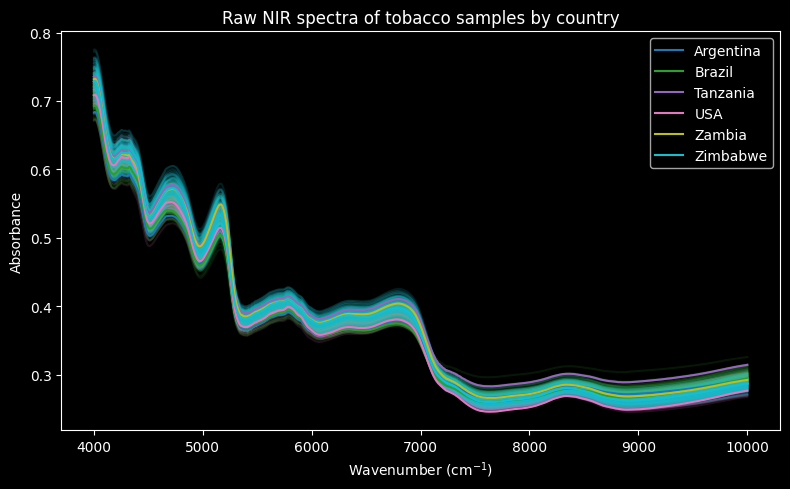

In [ ]:
# 1) Identify metadata and spectral columns
meta_cols = ['Sample ID', 'Planting year', 'Country']
spec_cols = [c for c in df.columns if c not in meta_cols]

# 2) Feature matrix X and labels y
X = df[spec_cols].values  # shape (347, ~1557)
y = df['Country'].values

# 3) Wavenumbers as floats (for plotting loadings later)
wavenumbers = np.array(spec_cols, dtype=float)

countries = np.unique(y)

plt.figure(figsize=(8, 5))

# All spectra, semitransparent lines
for country in countries:
    idx = (y == country)
    color = COUNTRY_COLORS.get(country, COUNTRY_COLORS["Other"])
    for row in X[idx]:
        plt.plot(wavenumbers, row, color=color, alpha=0.15)
        
# Plot one representative spectrum per country for the legend
for country in countries:
    idx = (y == country)
    color = COUNTRY_COLORS.get(country, COUNTRY_COLORS["Other"])
    plt.plot(wavenumbers, X[idx][0], color=color, label=country)

plt.gca()

plt.xlabel("Wavenumber (cm$^{-1}$)")
plt.ylabel("Absorbance")
plt.title("Raw NIR spectra of tobacco samples by country")
plt.legend()
plt.tight_layout()
plt.show()


A line plot of all raw NIR spectra, coloured by country, shows that the spectra are highly similar in overall shape with strong overlap between countries. This suggests that simple visual inspection of the raw spectra is not sufficient to separate geographical origins, as such Principal Component Analysis (PCA) was a natural next step.


## Principal Component Analysis (PCA)

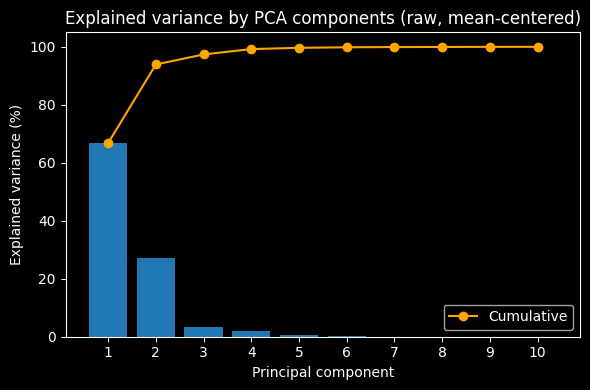

In [60]:
# Mean-centering only (no variance scaling) to keep all spectral variables on the same scale
X_mean = X.mean(axis=0)
X_centered = X - X_mean

# PCA on mean-centred spectra
pca = PCA(n_components=10)
T = pca.fit_transform(X_centered)
P = pca.components_
explained_var = pca.explained_variance_ratio_

# Bar + cumulative curve of explained variance per component
plt.figure(figsize=(6, 4))
plt.bar(range(1, len(explained_var) + 1), explained_var * 100, color="#1f77b4")
plt.plot(
    range(1, len(explained_var) + 1),
    np.cumsum(explained_var) * 100,
    marker='o', color='orange', label='Cumulative'
)
plt.xlabel("Principal component")
plt.ylabel("Explained variance (%)")
plt.title("Explained variance by PCA components (raw, mean-centered)")
plt.xticks(range(1, len(explained_var) + 1))
plt.legend()
plt.tight_layout()
plt.show()


#### Explained variance of each 10 components

In [ ]:
# Create a table with explained and cumulative variance per principal component
pc_indices = np.arange(1, len(explained_var) + 1)

explained_pct = explained_var * 100
cum_explained_pct = np.cumsum(explained_var) * 100

explained_df = pd.DataFrame({
    "PC": pc_indices,
    "Explained_variance_%": explained_pct,
    "Cumulative_%": cum_explained_pct
})

print(explained_df.to_string(index=False, float_format="%.2f"))

 PC  Explained_variance_%  Cumulative_%
  1                 66.76         66.76
  2                 27.13         93.89
  3                  3.45         97.34
  4                  1.86         99.19
  5                  0.43         99.63
  6                  0.19         99.82
  7                  0.07         99.89
  8                  0.04         99.93
  9                  0.03         99.96
 10                  0.01         99.97


PC1 + PC2 explain ~ 94 % of the variance, and including PC3 ~ 97% is explained. We will explore these further.

### PCA Score plots

#### PCA score plots of all pair-combinations of PC1-PC3

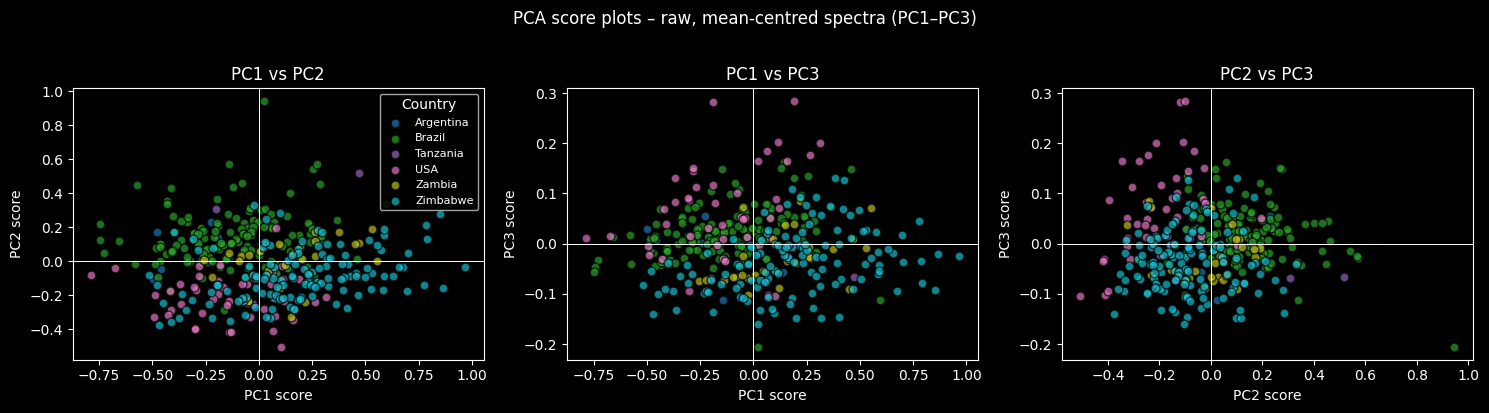

In [62]:
pc1 = T[:, 0]
pc2 = T[:, 1]
pc3 = T[:, 2]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=False, sharey=False)

# PC1 vs PC2
ax = axes[0]
for country in countries:
    idx = (y == country)
    ax.scatter(
        pc1[idx], pc2[idx],
        color=COUNTRY_COLORS[country],
        label=country, alpha=0.7, edgecolor='k', s=40
    )
ax.axhline(0, color='white', linewidth=0.7)
ax.axvline(0, color='white', linewidth=0.7)
ax.set_xlabel("PC1 score")
ax.set_ylabel("PC2 score")
ax.set_title("PC1 vs PC2")

# PC1 vs PC3
ax = axes[1]
for country in countries:
    idx = (y == country)
    ax.scatter(
        pc1[idx], pc3[idx],
        color=COUNTRY_COLORS[country],
        alpha=0.7, edgecolor='k', s=40
    )
ax.axhline(0, color='white', linewidth=0.7)
ax.axvline(0, color='white', linewidth=0.7)
ax.set_xlabel("PC1 score")
ax.set_ylabel("PC3 score")
ax.set_title("PC1 vs PC3")

# PC2 vs PC3
ax = axes[2]
for country in countries:
    idx = (y == country)
    ax.scatter(
        pc2[idx], pc3[idx],
        color=COUNTRY_COLORS[country],
        alpha=0.7, edgecolor='k', s=40
    )
ax.axhline(0, color='white', linewidth=0.7)
ax.axvline(0, color='white', linewidth=0.7)
ax.set_xlabel("PC2 score")
ax.set_ylabel("PC3 score")
ax.set_title("PC2 vs PC3")

axes[0].legend(title="Country", fontsize=8)

fig.suptitle("PCA score plots – raw, mean-centred spectra (PC1–PC3)", y=1.02)
plt.tight_layout()
plt.show()


#### PCA score plots of all the different countries (PC1 and PC2)

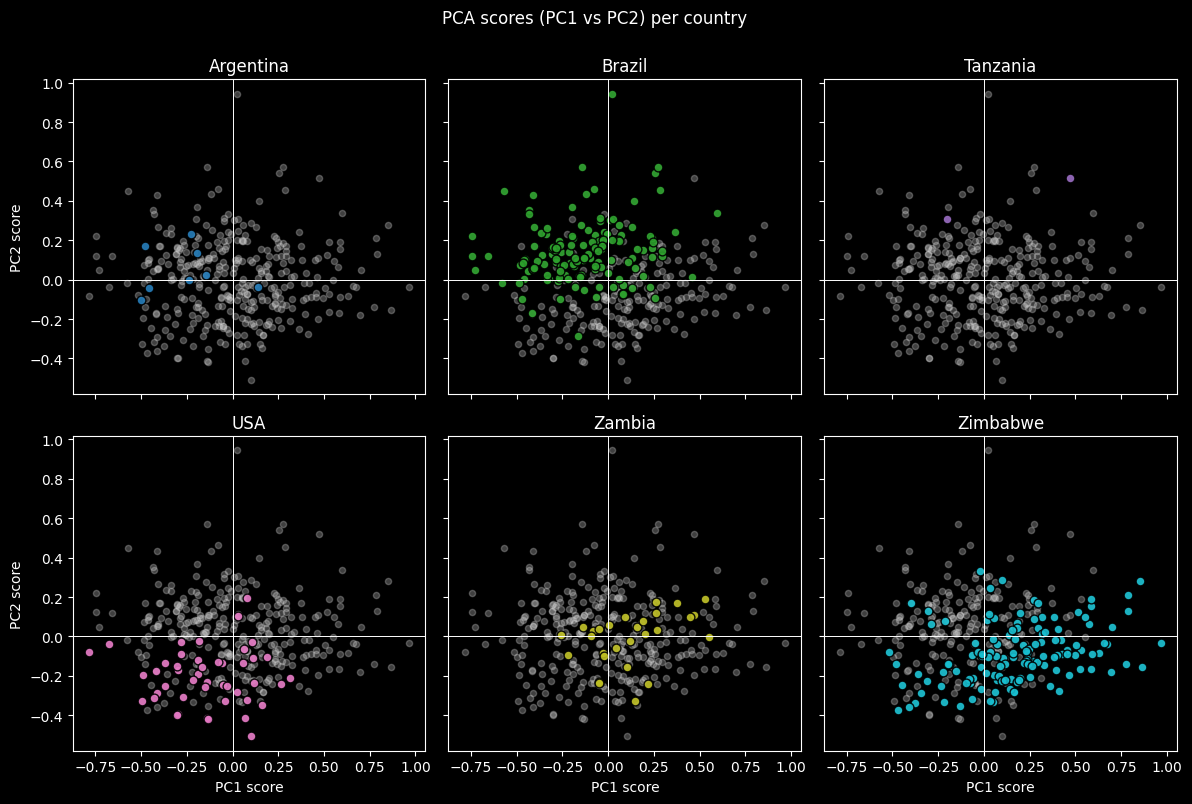

In [63]:
pc1 = T[:, 0]
pc2 = T[:, 1]

# PCA score plots (PC1 vs PC2) shown separately for each country
n_rows, n_cols = 2, 3
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(4 * n_cols, 4 * n_rows),
    sharex=True, sharey=True
)
axes = axes.ravel()

for i, country in enumerate(countries):
    ax = axes[i]
    idx = (y == country)

    # All samples in gray (background)
    ax.scatter(
        pc1, pc2,
        color='lightgrey', alpha=0.3, s=20, label='_nolegend_'
    )

    # Current country in its own color
    ax.scatter(
        pc1[idx], pc2[idx],
        color=COUNTRY_COLORS[country], alpha=0.9, s=40,
        edgecolor='k', label=country
    )

    ax.axhline(0, color='white', linewidth=0.7)
    ax.axvline(0, color='white', linewidth=0.7)
    ax.set_title(country)

    # Axis labels only on left column / bottom row to avoid clutter
    if i % n_cols == 0:
        ax.set_ylabel("PC2 score")
    if i // n_cols == n_rows - 1:
        ax.set_xlabel("PC1 score")

fig.suptitle("PCA scores (PC1 vs PC2) per country", y=1)
plt.tight_layout()
plt.show()


#### PCA of different planting years

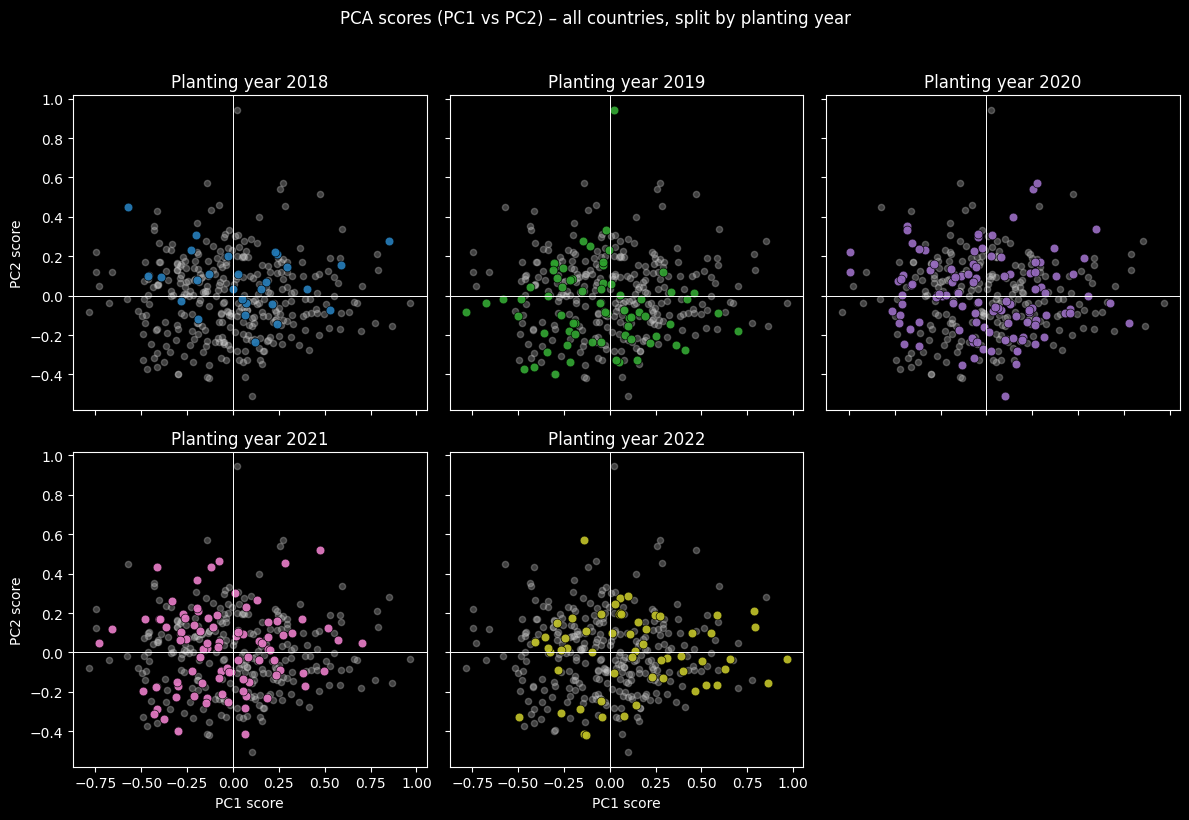

In [64]:
pc1 = T[:, 0]
pc2 = T[:, 1]

years_all = df['Planting year'].values
years = np.sort(np.unique(years_all))

# PCA score plots (PC1 vs PC2) for all samples, split by planting year
n_years = len(years)
n_rows = 2
n_cols = int(np.ceil(n_years / n_rows))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(4 * n_cols, 4 * n_rows),
    sharex=True,
    sharey=True
)
axes = axes.ravel()

for i, year in enumerate(years):
    ax = axes[i]
    idx_year = (years_all == year)

    # All samples in gray (background)
    ax.scatter(
        pc1, pc2,
        color='lightgrey', alpha=0.3,
        s=20, label='_nolegend_'
    )

    # Samples from this year in color
    color = YEAR_COLORS.get(year, YEAR_COLORS["Other"])
    ax.scatter(
        pc1[idx_year], pc2[idx_year],
        color=color, alpha=0.9,
        s=40, edgecolor='k', linewidth=0.5,
        label=str(year)
    )

    ax.axhline(0, color='white', linewidth=0.7)
    ax.axvline(0, color='white', linewidth=0.7)
    ax.set_title(f"Planting year {year}")

    # Axis labels only on outer plots to avoid clutter
    if i % n_cols == 0:
        ax.set_ylabel("PC2 score")
    if i // n_cols == n_rows - 1:
        ax.set_xlabel("PC1 score")

# Remove empty panels if grid has more slots than years
for j in range(i + 1, n_rows * n_cols):
    fig.delaxes(axes[j])

fig.suptitle(
    "PCA scores (PC1 vs PC2) – all countries, split by planting year",
    y=1.02
)
plt.tight_layout()
plt.show()

#### PCA score plot with PC1 vs PC2 scores for chosen country/contries, split by planting year.

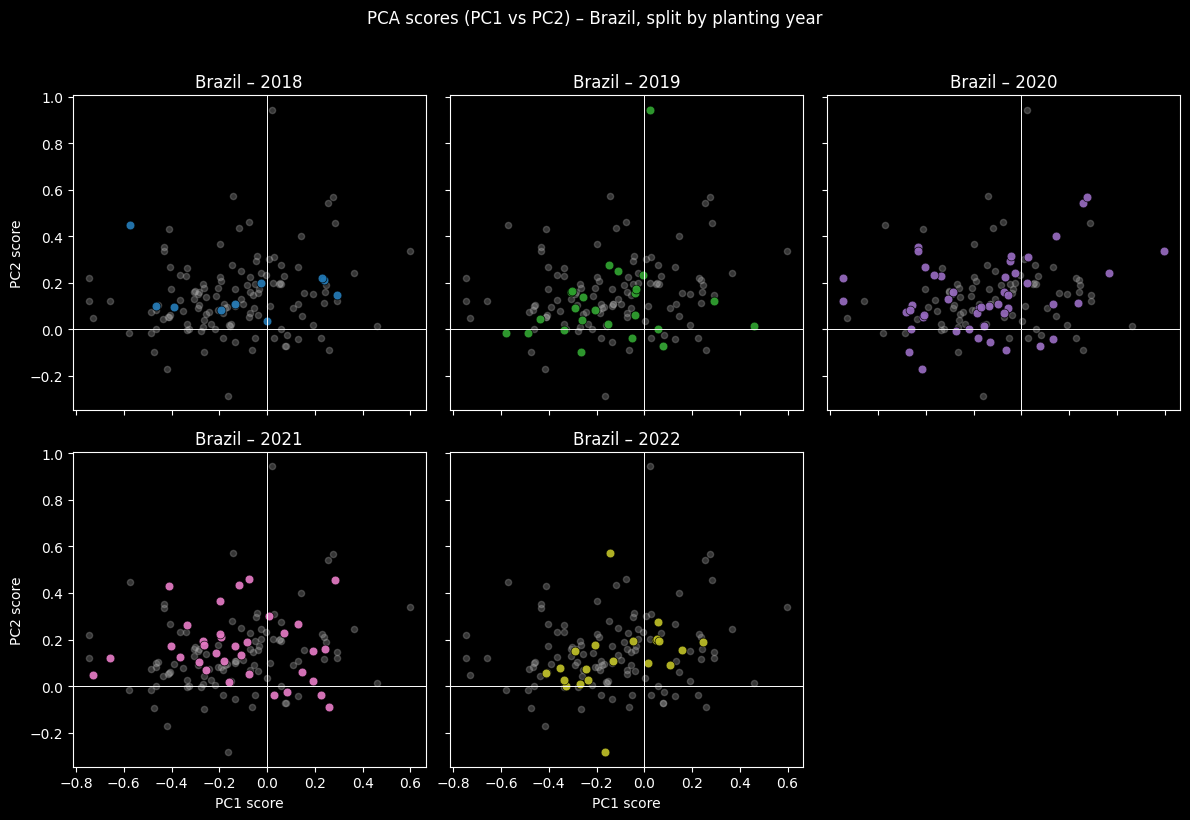

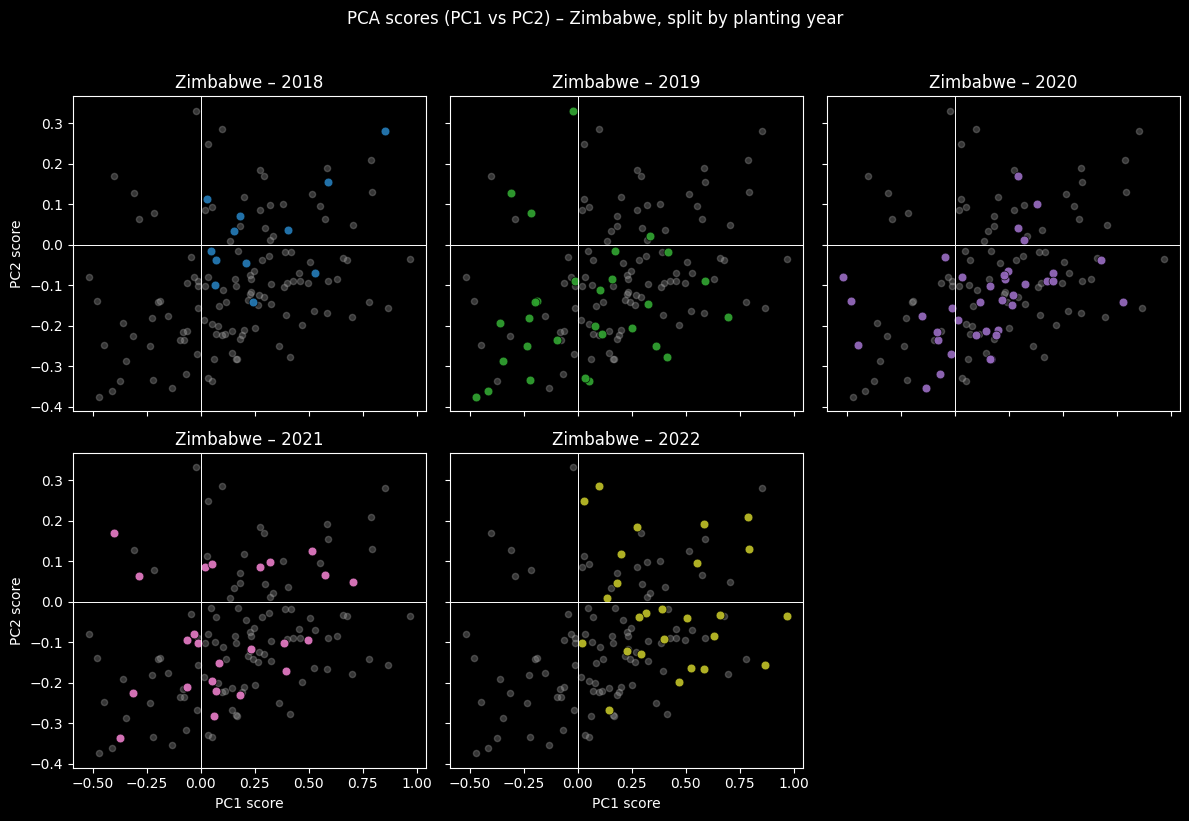

In [ ]:
pc1 = T[:, 0]
pc2 = T[:, 1]

def plot_country_by_year(country_name):
    
    # Filter to the selected country
    mask_country = (df['Country'].values == country_name)
    pc1_c = pc1[mask_country]
    pc2_c = pc2[mask_country]
    years_c = df.loc[mask_country, 'Planting year'].values

    # Unique planting years for this country
    years = np.sort(np.unique(years_c))
    n_panels = len(years)

    # Subplot layout: 2 rows
    n_rows = 2
    n_cols = int(np.ceil(n_panels / n_rows))

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(4 * n_cols, 4 * n_rows),
        sharex=True,
        sharey=True
    )
    axes = axes.ravel()

    # Plot each planting year
    for i, year in enumerate(years):
        ax = axes[i]
        idx_year = (years_c == year)

        # All samples for this country (background)
        ax.scatter(
            pc1_c, pc2_c,
            color=YEAR_COLORS["Other"],
            alpha=0.3,
            s=20,
            label='_nolegend_'
        )

        # Samples from this year in color
        color = YEAR_COLORS.get(year, YEAR_COLORS["Other"])
        ax.scatter(
            pc1_c[idx_year],
            pc2_c[idx_year],
            color=color,
            alpha=0.9,
            s=40,
            edgecolor='k',
            linewidth=0.5,
            label=str(year)
        )

        ax.axhline(0, color='white', linewidth=0.7)
        ax.axvline(0, color='white', linewidth=0.7)
        ax.set_title(f"{country_name} – {year}")

        # Axis labels only on outer plots
        if i % n_cols == 0:
            ax.set_ylabel("PC2 score")
        if i // n_cols == n_rows - 1:
            ax.set_xlabel("PC1 score")

    # Remove empty panels if fewer years than grid cells
    for j in range(i + 1, n_rows * n_cols):
        fig.delaxes(axes[j])

    fig.suptitle(
        f"PCA scores (PC1 vs PC2) – {country_name}, split by planting year",
        y=1.02
    )

    plt.tight_layout()
    plt.show()


plot_country_by_year("Brazil")
plot_country_by_year("Zimbabwe")
# plot_country_by_year("USA")
# plot_country_by_year("Zambia")
# plot_country_by_year("Argentina")
# plot_country_by_year("Tanzania")


## Outlier detection

#### Z-score method

In [65]:
# Use the first two PC scores as input to the z-score outlier analysis
scores = T[:, :2]  # PC1 and PC2

# Standardise scores per component (z-score)
mean_scores = scores.mean(axis=0)
std_scores = scores.std(axis=0, ddof=1)
z_scores = (scores - mean_scores) / std_scores  # shape (N, 2)

# Euclidean distance in z-score space
dist = np.linalg.norm(z_scores, axis=1)

# Outlier threshold, e.g., 3 standard deviations (rule of thumb)
threshold = 3.0
outlier_idx = np.where(dist > threshold)[0]

print("Number of potential outliers:", len(outlier_idx))
print("Indices:", outlier_idx)

# Create a small summary table for the potential outliers
outlier_df = df.iloc[outlier_idx][['Sample ID', 'Country', 'Planting year']].copy()
outlier_df['PC1'] = scores[outlier_idx, 0]
outlier_df['PC2'] = scores[outlier_idx, 1]
outlier_df['dist_PC1_2_z'] = dist[outlier_idx]

print(outlier_df.to_string(index=False, float_format="%.3f"))

Number of potential outliers: 3
Indices: [101 218 249]
 Sample ID  Country  Planting year   PC1    PC2  dist_PC1_2_z
       102   Brazil           2019 0.022  0.944         4.724
       219 Zimbabwe           2022 0.968 -0.036         3.092
       250 Zimbabwe           2018 0.851  0.280         3.055


#### Mahalanobis-distance

In [66]:
# Use the first three PC scores for Mahalanobis outlier analysis
scores = T[:, :3]  # shape (n_samples, 3)

# Covariance and inverse covariance matrix in PC space
cov = np.cov(scores, rowvar=False)
cov_inv = np.linalg.inv(cov)

# Centre of the scores in PC space
mean_scores = scores.mean(axis=0)

# Mahalanobis distance of each sample to the centre
d_mahal = np.array([
    mahalanobis(s, mean_scores, cov_inv)
    for s in scores
])

# Threshold, e.g., top 2 % as candidate outliers
percentile = 98
thr_mahal = np.percentile(d_mahal, percentile)

# Indices of candidate outliers
outlier_idx = np.where(d_mahal > thr_mahal)[0]

print(f"Number of Mahalanobis candidates: {len(outlier_idx)}")
print("Indices (0-based):", outlier_idx.tolist())

# Summary table with index, Sample ID, country, year and distance
outlier_df = df.iloc[outlier_idx][['Sample ID', 'Country', 'Planting year']].copy()
outlier_df['global_index'] = outlier_idx
outlier_df['Mahalanobis_PC1_3'] = d_mahal[outlier_idx]

print("\nDetails for candidate outliers:")
print(outlier_df.to_string(index=False, float_format="%.3f"))

Number of Mahalanobis candidates: 7
Indices (0-based): [101, 218, 249, 276, 285, 309, 317]

Details for candidate outliers:
 Sample ID  Country  Planting year  global_index  Mahalanobis_PC1_3
       102   Brazil           2019           101              5.543
       219 Zimbabwe           2022           218              3.112
       250 Zimbabwe           2018           249              3.324
       277      USA           2018           276              4.053
       286      USA           2020           285              3.178
       310      USA           2019           309              4.076
       318 Tanzania           2021           317              3.135


## PCA plots with potential outliers marked (PC1 and PC2 + PC1 and PC3)

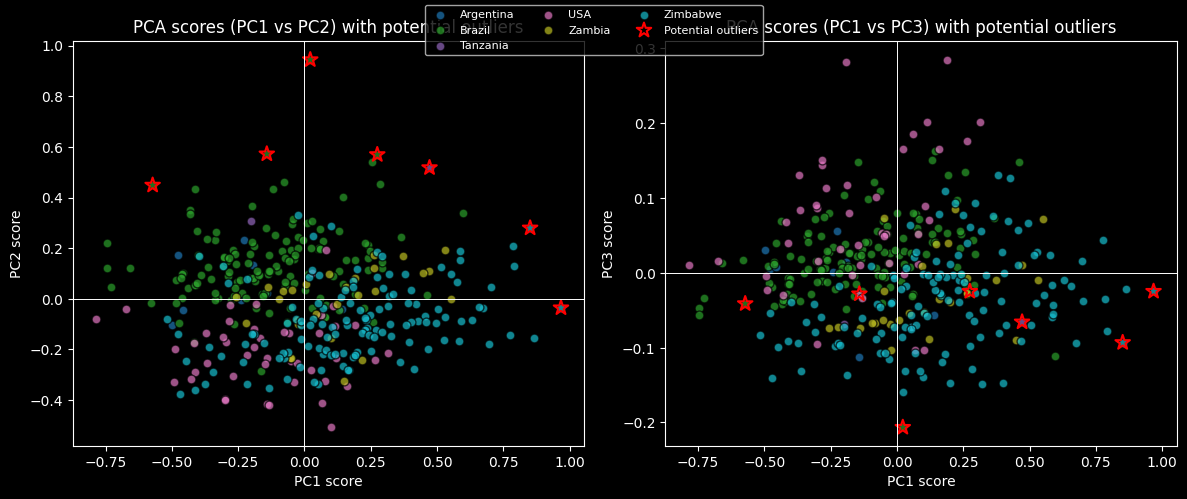

In [59]:
def plot_pca_with_outliers_on_ax(ax, pc_x, pc_y, xlabel, ylabel, title):
    """Scatter plot of PC scores coloured by country, with potential outliers highlighted."""
    # All points by country
    for country in countries:
        idx = (y == country)
        ax.scatter(
            pc_x[idx], pc_y[idx],
            color=COUNTRY_COLORS.get(country, COUNTRY_COLORS["Other"]),
            alpha=0.7, edgecolor='k', s=40, label=country
        )

    # Outliers: red stars
    ax.scatter(
        pc_x[outlier_idx], pc_y[outlier_idx],
        facecolors='none', edgecolors='red',
        s=120, marker='*', linewidths=1.5,
        label='Potential outliers'
    )

    ax.axhline(0, color='white', linewidth=0.7)
    ax.axvline(0, color='white', linewidth=0.7)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)


# Scores
pc1 = T[:, 0]
pc2 = T[:, 1]
pc3 = T[:, 2]

# Ensure that outlier_idx is a NumPy array
outlier_idx = np.array(outlier_idx)

# Create a single figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=False, sharey=False)

# Left: PC1 vs PC2
plot_pca_with_outliers_on_ax(
    axes[0],
    pc1, pc2,
    xlabel="PC1 score",
    ylabel="PC2 score",
    title="PCA scores (PC1 vs PC2) with potential outliers"
)

# Right: PC1 vs PC3
plot_pca_with_outliers_on_ax(
    axes[1],
    pc1, pc3,
    xlabel="PC1 score",
    ylabel="PC3 score",
    title="PCA scores (PC1 vs PC3) with potential outliers"
)

# One shared legend (take handles/labels from first axis)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, fontsize=8)

plt.tight_layout()
plt.show()

### PCA plots of the different countries with potential outliers

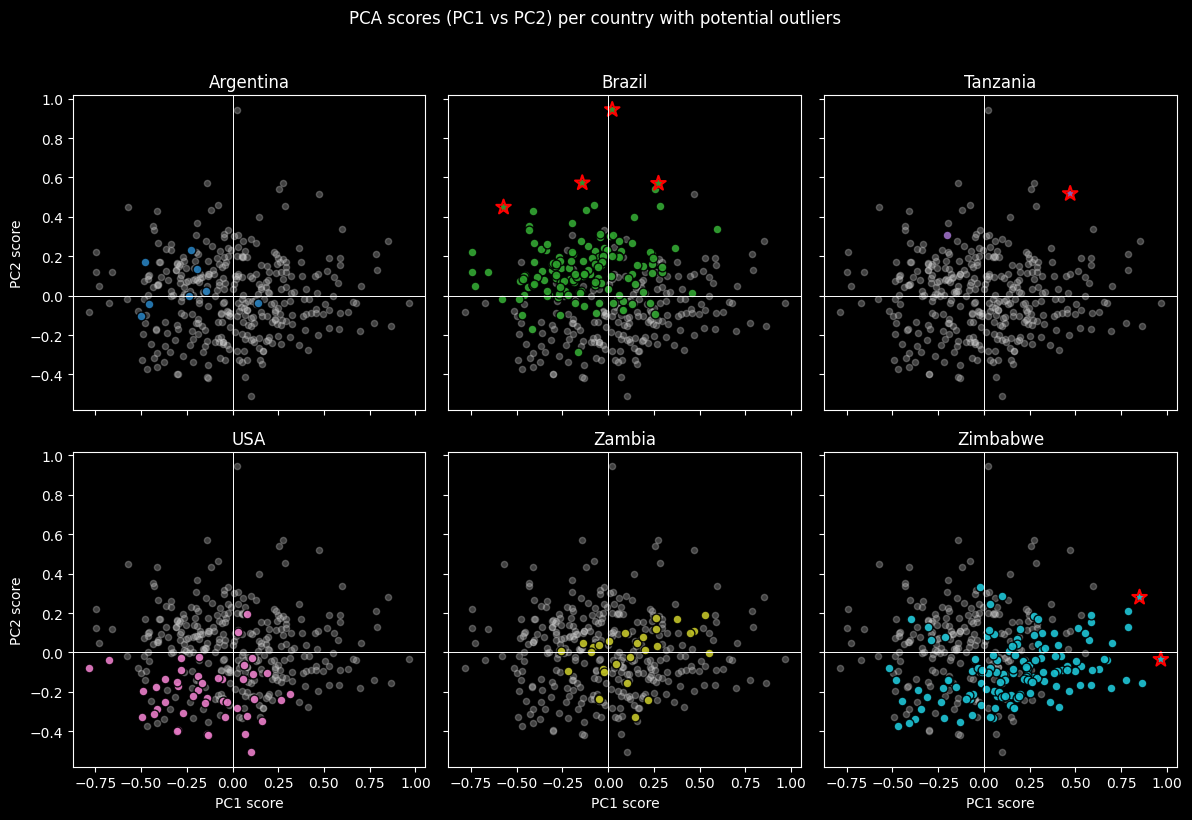

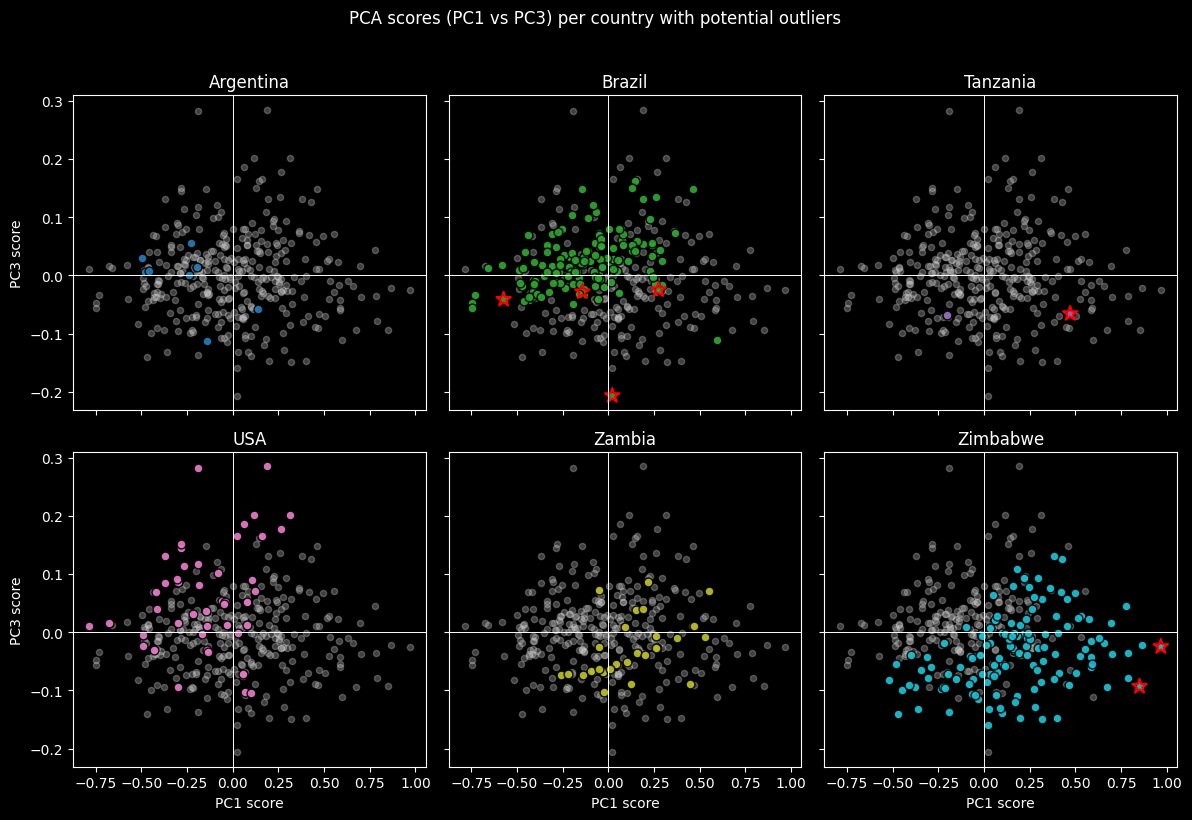

In [ ]:
def plot_countries_with_outliers(pc_x, pc_y, y, countries, outlier_idx,
                                 xlabel, ylabel, title):
    n_rows, n_cols = 2, 3
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(4 * n_cols, 4 * n_rows),
        sharex=True, sharey=True
    )
    axes = axes.ravel()

    outlier_idx = np.array(outlier_idx)

    for i, country in enumerate(countries):
        ax = axes[i]
        idx_country = (y == country)

        # All samples in gray
        ax.scatter(
            pc_x, pc_y,
            color='lightgrey', alpha=0.3, s=20, label='_nolegend_'
        )

        # This country in its fixed color
        ax.scatter(
            pc_x[idx_country], pc_y[idx_country],
            color=COUNTRY_COLORS.get(country, COUNTRY_COLORS["Other"]),
            alpha=0.9, s=40, edgecolor='k', label=country
        )

        # Outliers for this country
        idx_out_country = idx_country & np.isin(np.arange(len(y)), outlier_idx)
        if idx_out_country.any():
            ax.scatter(
                pc_x[idx_out_country], pc_y[idx_out_country],
                facecolors='none', edgecolors='red',
                s=120, marker='*', linewidths=1.5,
                label='Potential outlier(s)'
            )

        ax.axhline(0, color='white', linewidth=0.7)
        ax.axvline(0, color='white', linewidth=0.7)
        ax.set_title(country)

        if i % n_cols == 0:
            ax.set_ylabel(ylabel)
        if i // n_cols == n_rows - 1:
            ax.set_xlabel(xlabel)

    # Remove empty axes if fewer than 6 countries
    for j in range(i + 1, n_rows * n_cols):
        fig.delaxes(axes[j])

    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()



plot_countries_with_outliers(
    pc1, pc2, y, countries, outlier_idx,
    xlabel="PC1 score",
    ylabel="PC2 score",
    title="PCA scores (PC1 vs PC2) per country with potential outliers"
)

plot_countries_with_outliers(
    pc1, pc3, y, countries, outlier_idx,
    xlabel="PC1 score",
    ylabel="PC3 score",
    title="PCA scores (PC1 vs PC3) per country with potential outliers"
)

## Conclusion regarding outliers and PC-dimension

We conclude that no samples will be removed as outliers, even though both the z‑score and Mahalanobis analyses flag sample 101 (and a few others) as potential outliers. The dataset is not very large, so removing rare but valid samples would reduce the representativeness of the data. Furthermore, our domain knowledge of tobacco NIR spectra is limited, so we cannot confidently classify these samples irrelevant. Even though in the PCA score plots, some of the flagged samples lie far away from the clusters, they might instead reflect genuinely rare but informative cases that the model should be able to capture.

---

For further work we will focus on two-dimensional PCA representasion (PC1-PC2), even though PC3 adds an additional 3 % of the total variance. PC1 and PC2 together explained approximately 94 %, therefore provide a good balance between retaining most of the variance and keeping the plots interpretable and easy to compare across preprocessing methods.